# 불균형 데이터 처리
- 클래스간 데이터 불균형이 심할 경우 우세한 데이터 클래스를 택하는 모형의 정확도가 높아지므로 데이터의 편향이 발생
- 데이터간의 균형 맞추는 방법
    - 가중치 균형 : 각 클래스별 특정 비율로 가중치를 주어서 분석하거나 결과를 도출
        - 가중치를 직접 데이터에 반영할 수 있지만, 일반적으로 분석단계(모델학습)에서 가중치를 적용
    - 언더샘플링 : 대표클래스의 일부 데이터만 사용하여 소수클래스와 동일한 비율로 만드는 방법
    - 오버샘플링 : 대표클래스의 수만큼 소수 클래스의 데이터를 증가시는 방법

In [ ]:
# 남자가 70% 여자가 30% 라고 하면 남자가 더 우세한 데이터가 수집될 수 밖에 없기 때문
# 범주형 카테고리가 필요한 경우 클래스 간의 비율이 유사해야 한다
# 불균형 확인 방법
#  - 파이차트, 히스토그램 확인
#  - value들 count  등등..

# 불균형 데이터 처리 방법
# 1. 가중치 균형 : 분류 분석시 클래스간 균형을 맞춘다.
# - 여자 : 남자 = 3 : 7 이라고 할 때
#   10 / 3: 10 / 7로 분석
# - balance 라는 딕셔너리 타입을 주어서 따로 밸런스를 맞추는 방법도 가능
# 2. 언더 샘플링 : 소수클래스와 동일하게
# 3. 오버 샘플링 : 소수클래스를 증가시킴
# ㄴ 밑의 imblearn 사용해서 해볼거야

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## imblearn (imbalanced-learn) 라이브러리
- 불균형 데이터셋을 처리하는 데 특화된 라이브러리
- 불균형 클래스 문제를 해결하기 위해 오버샘플링, 언더샘플링, 앙상블 기법 등 다양한 방법을 제공
- https://imbalanced-learn.org/stable/index.html
```
!pip install imblearn
```

https://imbalanced-learn.org/stable/over_sampling.html

## 오버샘플링
- 랜덤 오버 샘플링(Random Over-Sampling)
    - 소수 클래스의 샘플을 무작위로 복제
    - 원본 데이터가 정규분포를 따를 경우, 해당 정규분포에서 랜덤 데이터 샘플링 가능
- SMOTE(Synthetic Minority Oversampling Technique)
    - 최근접 이웃 규칙을 통해 소수 클래스의 데이터를 합성하여 새로운 데이터를 생성
- ADASYN(Adaptive Synthetic)
    - SMOTE에서 발전된 기법으로, 클래스간의 분류된 경계를 중심으로 SMOTE기법을 활용하여 데이터를 생성

In [ ]:
# - 랜덤 오버 샘플링
# 다수의 클래스의 크기와 동일해지도록 소수의 클래스 샘플 무작위 복제
# 불균형이 너무 클 경우 오히려 똑같이 불균형이 일어날 수 있음 (너무 중복된 데이터 많아질 수 있음)
# 산점도로는 파악 불가(복제이기 때문에 산점도가 겹침)

# 소수 너무 작아 복제했을 때 문제가 생기는 경우 사용할 수 있는 방법
# 가지고 있는 데이터에서 그 분포를 이용해 가져오는 방법
# - SMOTE(합성 소수 오버샘플링 테크닉) : 분포에서 다양하게 (가장 많이 사용)
# 소수의 클래스의 값들을 중심으로 (여러 데이터들의) 평균을 정해서
# 중심점을 만들어 새로운 데이터 생성
# - ADASYN(Adaptive Synthetic) : 경계값 강화(경계 데이터 많이 만듬)
# smote 중에서도 클래스간 경계를 중심으로 smote 기법
# 분류된 경계? -> 다수의 클래스가 있고 소수의 클래스의 데이터들이 있다고 할 때
# 소수의 클래스 데이터들을 이어 경계를 만들고(모두 잇진 않음) 그 안에서 smote 기법으로 데이터를 만든다.

In [24]:
# 데이터프레임 생성
np.random.seed(42)
x1 = np.random.uniform(0, 10, 10)
x2 = np.random.uniform(0, 10, 10)
y = np.random.choice([0, 1], 10)
data = {
    "X1": x1, "X2": x2, "label": y
}
df = pd.DataFrame(data)

# 클래스별 데이터 분리
# 어떤게 클래스가 큰지, 작은지 판단
class_0 = df[df["label"] == 0]
class_1 = df[df["label"] == 1]
print('class_0: ', len(class_0), 'class_1:', len(class_1)) # class_0 : 3, class_1 : 7

# 소수 클래스 데이터 복제
n_samples_add = len(class_1) - len(class_0)  # 추가할 샘플 수(7-3= 4개 복제)
oversampled = class_0.iloc[np.random.choice(len(class_0), n_samples_add, replace=True)]

# 데이터 합치기
df_over_np = pd.concat([df, oversampled]) # 위아래로 concat
df_over_np.groupby('label').size() # 두개 다 7개 인 것 확인

         X1        X2  label
0  3.745401  0.205845      0
1  9.507143  9.699099      0
2  7.319939  8.324426      1
3  5.986585  2.123391      1
4  1.560186  1.818250      1
5  1.559945  1.834045      1
6  0.580836  3.042422      1
7  8.661761  5.247564      0
8  6.011150  4.319450      1
9  7.080726  2.912291      1
class_0:  3 class_1: 7


,0
label,
0,7
1,7


In [ ]:
# imblearn 라이브러리를 활용한 랜덤오버샘플링
from imblearn.over_sampling import RandomOverSampler

# 샘플러 객체 생성
ros = RandomOverSampler(random_state=42) #재현성을 위해 random_state=42으로 지정

# X와 y 분리
X = df.loc[:, 'X1':'X2']
y = df.loc[:, 'label']

# 샘플러를 통해 데이터 샘플링
X_over, y_over = ros.fit_resample(X, y) # 다시 샘플을 뽑아내는 작업

# 샘플링된 데이터를 데이터프레임으로 변환
df_over = pd.DataFrame(X_over)
df_over['label'] = y_over
df_over.groupby('label').size()

,0
label,
0,7
1,7


<Axes: xlabel='X1', ylabel='X2'>

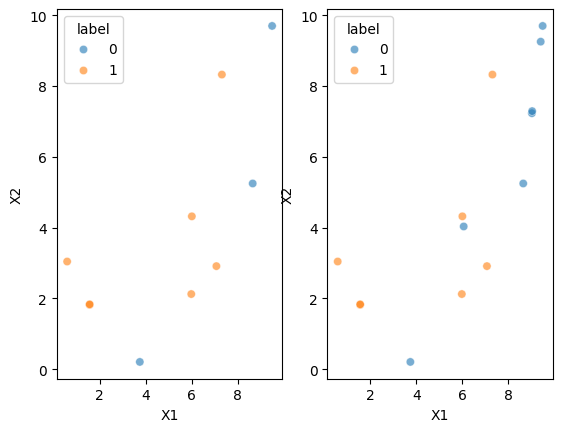

In [25]:
# SMOTE 오버샘플링
from imblearn.over_sampling import SMOTE, ADASYN

# 샘플러 객체 생성
smote = SMOTE(sampling_strategy='auto', k_neighbors= 2, random_state=42)
# k_neighbors : 몇개씩 묶을 건지 (default = 5)

# 샘플러를 통해 데이터 샘플링
X_smote, y_smote = smote.fit_resample(X, y)

# 샘플링된 데이터를 데이터프레임으로 변환
df_smote = pd.DataFrame(X_smote)
df_smote['label'] = y_smote
df_smote.groupby('label').size()

# 기존데이터와 변환된 데이터 산점도 확인
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="X1", y="X2", hue="label", alpha=0.6)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_smote, x="X1", y="X2", hue="label", alpha=0.6)

<Axes: xlabel='X1', ylabel='X2'>

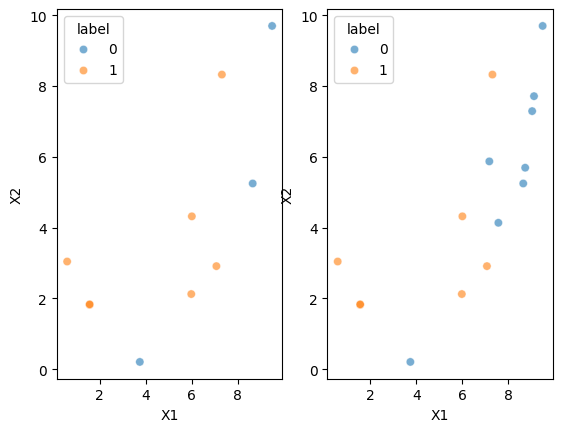

In [ ]:
# ADASYN 오버샘플링
from imblearn.over_sampling import ADASYN

# 샘플러 객체 생성
adasyn = ADASYN(sampling_strategy='auto', n_neighbors= 2, random_state=42)

# 샘플러를 통해 데이터 샘플링
X_adasyn, y_adasyn = adasyn.fit_resample(X, y)

# 샘플링된 데이터를 데이터프레임으로 변환
df_adasyn = pd.DataFrame(X_adasyn)
df_adasyn['label'] = y_adasyn

# 기존데이터와 변환된 데이터 산점도 확인
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="X1", y="X2", hue="label", alpha=0.6)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_adasyn, x="X1", y="X2", hue="label", alpha=0.6)

## 언더샘플링
- 랜덤 언더 샘플링(Random Under-Sampling)
    - 다수 클래스에 대한 데이터 하위 집합을 무작위로 선택
- 토멕 링크 방법(Tomek Link Method)
    - 토멕 링크는 서로 다른 클래스의 두 데이터가 서로 가장 가까운 이웃에 있는 데이터의 쌍
    - 데이터의 쌍 중 다수의 클래스에 해당하는 데이터 제거
    - 인접한 데이터가 없을 경우 제거되는 데이터가 없음
    - 소수 클래스와 다수 클래스 간의 경계를 명확하게 만들어 모델이 소수 클래스를 잘 분류할 수 있도록 함
- ENN(Edited Nearest Neighbours)
    - 최근접 이웃을 사용하여 소수 클래스 데이터의 이웃을 식별한 다음 이웃 중 다수 클래스의 데이터의 일부 또는 대부분을 제거
    - 다른 클래스와 거리가 가까운 모호한 데이터 제거
    - 소수 클래스와 다수 클래스 간의 경계를 강화하여 분석 성능 개선
- CNN(Condensed Nearest Neighbour)
    - 데이터를 줄이면서도 소수 클래스와의 경계를 잘 학습하기 위해 최소한의 데이터를 선택하는 방법
    - 소수 클래스의 모든 데이터의 최근접 이웃을 선택
    - 소수 클래스의 분류 경계를 강화하고, 다수 클래스의 불필요한 샘플을 제거하여 불균형 문제를 완화
- OSS(One Sided Seletion)
    - 토멕 링크와 CNN 기법의 장점을 통합한 방법
    - CNN을 통해 경계 데이터를 선택한 후, 근접한 데이터에 대해 토멕링크기법을 통해 다수의 클래스에 해당하는 데이터 제거
    - 소수 클래스의 분포를 강화하고, 다수 클래스의 노이즈를 제거하여 분석 성능 개선
- Tomek Links, ENN, CNN, OSS는 클래스간 동일한 비율을 보장하지 않음
    - 다수 클래스의 불필요한 데이터를 제거하고, 소수 클래스의 경계를 강화하여 모델이 소수 클래스를 더 잘 학습할 수 있도록 함
    - 필요시 샘플링된 데이터를 다시 오버샘플링을 통해 비율 조정

언더샘플링 같은 경우 노이즈가 많은 경우에 잘 사용한다.

In [3]:
# 소수 클래스 샘플 수에 맞춰 다수 클래스에서 랜덤 샘플링
undersampled = class_1.sample(n=len(class_0), random_state=42)

# 언더샘플링된 데이터프레임 병합
df_under_np = pd.concat([undersampled, class_0])
df_under_np.groupby('label').size()

,0
label,
0,3
1,3


In [4]:
# imblearn 라이브러리를 활용한 랜덤언더샘플링
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

# 샘플러 객체 생성
rus = RandomUnderSampler(random_state=42) #재현성을 위해 random_state=42로 지정

# X와 y 분리
X = df.loc[:, 'X1':'X2']
y = df.loc[:, 'label']

#샘플러를 통해 데이터 샘플링
X_under, y_under = rus.fit_resample(X, y)

# 샘플링된 데이터를 데이터프레임으로 변환
df_under = pd.DataFrame(X_under)
df_under['label'] = y_under
df_under.groupby('label').size()

,0
label,
0,3
1,3


In [5]:
from imblearn.under_sampling import TomekLinks

# 샘플러 객체 생성
tomek = TomekLinks()

#샘플러를 통해 데이터 샘플링
X_tomek, y_tomek = tomek.fit_resample(X, y)

# 샘플링된 데이터를 데이터프레임으로 변환
df_tomek = pd.DataFrame(X_tomek)
df_tomek['label'] = y_tomek
df_tomek.groupby('label').size()

# 인접한 데이터가 없어 그대로 3, 6으로 나온다.

,0
label,
0,3
1,6


label
0    3
1    6
dtype: int64


<Axes: xlabel='X1', ylabel='X2'>

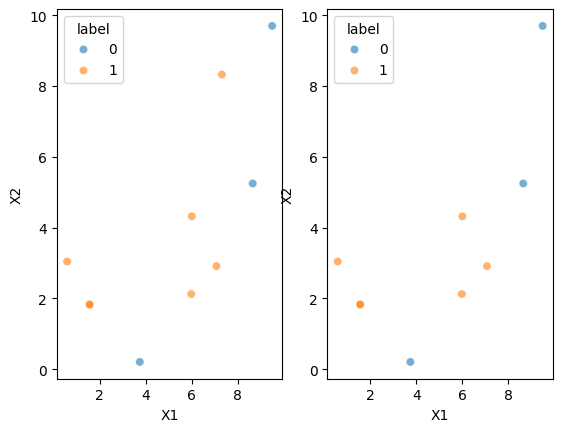

In [7]:
from imblearn.under_sampling import EditedNearestNeighbours

# 샘플러 객체 생성
enn = EditedNearestNeighbours(n_neighbors=2) # 몇개씩 묶을 건지

#샘플러를 통해 데이터 샘플링
X_enn, y_enn = enn.fit_resample(X, y)

# 샘플링된 데이터를 데이터프레임으로 변환
df_enn = pd.DataFrame(X_enn)
df_enn['label'] = y_enn
print(df_enn.groupby('label').size())

# 기존데이터와 변환된 데이터 산점도 확인
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="X1", y="X2", hue="label", alpha=0.6)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_enn, x="X1", y="X2", hue="label", alpha=0.6)

# 근접데이터가 없어 그대로 3개, 6개로

label
0    3
1    4
dtype: int64


<Axes: xlabel='X1', ylabel='X2'>

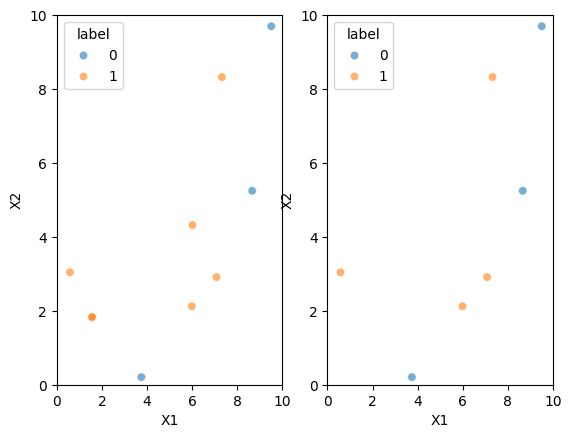

In [8]:
from imblearn.under_sampling import CondensedNearestNeighbour

# 샘플러 객체 생성
cnn = CondensedNearestNeighbour(n_neighbors=2, random_state=42)

#샘플러를 통해 데이터 샘플링
X_cnn, y_cnn = cnn.fit_resample(X, y)

# 샘플링된 데이터를 데이터프레임으로 변환
df_cnn = pd.DataFrame(X_cnn)
df_cnn['label'] = y_cnn
print(df_cnn.groupby('label').size())

# 기존데이터와 변환된 데이터 산점도 확인
plt.subplot(1, 2, 1)
plt.xlim(0,10)
plt.ylim(0,10)
sns.scatterplot(data=df, x="X1", y="X2", hue="label", alpha=0.6)
plt.subplot(1, 2, 2)
plt.xlim(0,10)
plt.ylim(0,10)
sns.scatterplot(data=df_cnn, x="X1", y="X2", hue="label", alpha=0.6)

label
0    3
1    3
dtype: int64


<Axes: xlabel='X1', ylabel='X2'>

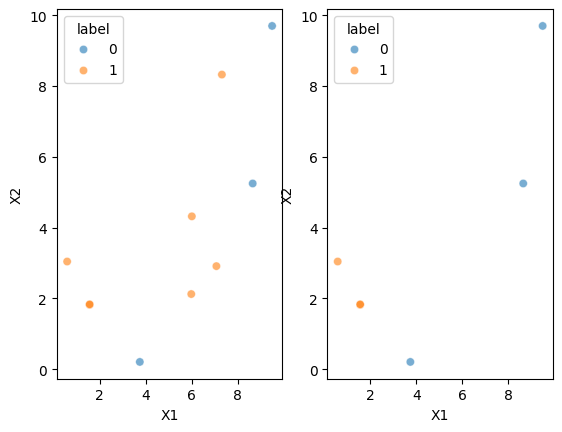

In [9]:
from imblearn.under_sampling import OneSidedSelection

# 샘플러 객체 생성
oss = OneSidedSelection(random_state=42)

#샘플러를 통해 데이터 샘플링
X_oss, y_oss = oss.fit_resample(X, y)

# 샘플링된 데이터를 데이터프레임으로 변환
df_oss = pd.DataFrame(X_oss)
df_oss['label'] = y_oss
print(df_oss.groupby('label').size())

# 기존데이터와 변환된 데이터 산점도 확인
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="X1", y="X2", hue="label", alpha=0.6)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_oss, x="X1", y="X2", hue="label", alpha=0.6)

### 택시 데이터의 불균형 처리

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# 택시 데이터 불러오기
taxis = pd.read_csv('/content/drive/MyDrive/taxis/df_taxis_pca.csv')
taxis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6329 entries, 0 to 6328
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pickup                 6329 non-null   object 
 1   dropoff                6329 non-null   object 
 2   passengers             6329 non-null   int64  
 3   distance               6329 non-null   float64
 4   fare                   6329 non-null   float64
 5   tip                    6329 non-null   float64
 6   tolls                  6329 non-null   float64
 7   total                  6329 non-null   float64
 8   color                  6329 non-null   object 
 9   payment                6329 non-null   object 
 10  pickup_zone            6329 non-null   object 
 11  dropoff_zone           6329 non-null   object 
 12  pickup_borough         6329 non-null   object 
 13  dropoff_borough        6329 non-null   object 
 14  ride_hour              6329 non-null   float64
 15  dist

In [13]:
# payment컬럼에 대한 데이터 비율 확인
# 방법1
taxis.groupby('payment').size()
# 방법 2
taxis['payment'].value_counts()
# 세배가까이 나는 비율 차이를 볼 수 있음

,count
payment,
credit card,4543
cash,1786


In [14]:
# 택시 데이터에 대해 payment에 대한 랜덤오버샘플링

# cash와 card 데이터 분리
cash = taxis[taxis['payment'] == 'cash']
card = taxis[taxis['payment'] == 'credit card']

# 샘플이 작은 cash를 무작위 복제
add_samples = len(card) - len(cash) # 추가할 샘플 수
# 둘의 수량을 모른다고 할 때 누가 더 수가 작은지에 따라 복제
if add_samples > 0 :
    oversampled = cash.iloc[np.random.choice(len(cash), add_samples, replace=True)]
elif add_samples < 0 :
    add_samples = abs(add_samples)
    oversampled = card.iloc[np.random.choice(len(card), add_samples, replace=True)]

# 복제된 데이터 병합
taxis_over_np = pd.concat([taxis, oversampled])
taxis_over_np.groupby('payment').size()


,0
payment,
cash,4543
credit card,4543


<Axes: xlabel='tip', ylabel='total'>

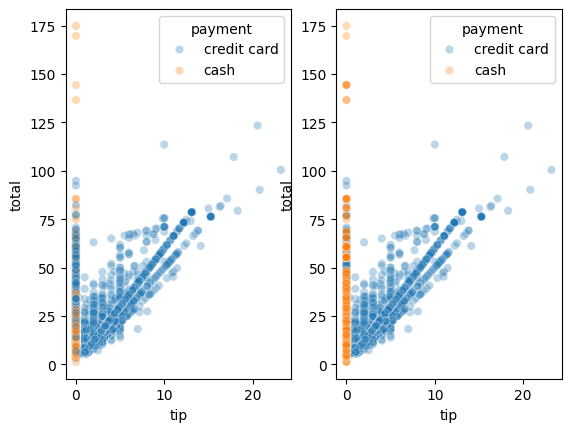

In [27]:
# 카테고리별로 데이터 분리 했다면
# 라이브러리에서는 x,y 분리해서 그것을 기준으로 데이터를 뽑는다.

# imblearn을 활용한 랜덤오버샘플링
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42) #재현성을 위해 random_state=42으로 지정

# X, y 데이터 분리
# X는 집합이니까 대문자 y는 하나이기 때문에 소문자
# payment column drop
X_payment = taxis.drop(columns=['payment'])
# payment 만 가져옴
y_payment = taxis['payment']

# 샘플링
X_over, y_over = ros.fit_resample(X_payment, y_payment)

# 데이터프레임 만들기
taxis_over = pd.DataFrame(X_over) # 먼저 만들어주고
taxis_over['payment'] = y_over    # 컬럼 추가
taxis_over['payment'].value_counts()

# 산점도 그리기
# 컬럼 이름만 넣어서도(x='tip') 사용 가능하고 그냥 데이터 프레임대로(y=taxis['total'])사용도 가능
plt.subplot(1,2,1)
sns.scatterplot(data=taxis, x='tip', y=taxis['total'], hue='payment', alpha =0.3)
# 주황색 데이터들이 진해진 것을 확인할 수 있다.
plt.subplot(1,2,2)
sns.scatterplot(data=taxis_over, x='tip', y='total', hue='payment', alpha =0.3)

payment
credit card    4543
cash           4543
Name: count, dtype: int64


<Axes: xlabel='tip', ylabel='total'>

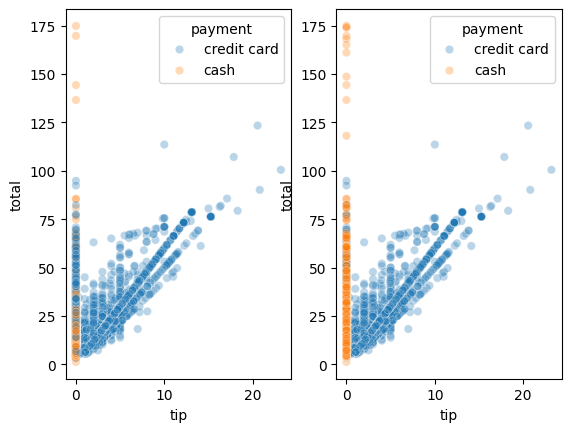

In [21]:
# smote를 이용한 랜덤오버샘플링
from imblearn.over_sampling import SMOTE

smote = SMOTE()

# X_payment가 이미 드롭된 형태 (앞에서)
# 거리 비교를 위해 smote는 숫자형변수만 (수치형데이터만) 사용
X_payment_num = X_payment.select_dtypes(include ='number')
# X_pament가 아니라 taxis에서 select_dtypes 해도됨
# ㄴ ex) X_payment_num = taxis.select_dtypes(include ='number')
# : payment 자체도 object이기 때문에 drop 된다.

# 샘플링
X_smote, y_smote = smote.fit_resample(X_payment_num, y_payment)

# 데이터 프레임 만들기
taxis_smote = pd.DataFrame(X_smote)
taxis_smote['payment'] = y_smote
print(taxis_smote['payment'].value_counts())

# 산점도 그리기
plt.subplot(1,2,1)
sns.scatterplot(data=taxis, x='tip', y='total', hue='payment', alpha =0.3)
# 주황색 데이터들이 진해진 것을 확인할 수 있다.
plt.subplot(1,2,2)
sns.scatterplot(data=taxis_smote, x='tip', y='total', hue='payment', alpha =0.3)

In [28]:
# 택시 데이터에 대해 payment에 대한 랜덤언더샘플링
# cash와 card 데이터 분리
cash = taxis[taxis['payment'] == 'cash']
card = taxis[taxis['payment'] == 'credit card']

# cash의 데이터 개수 만큼 카드를 만들어라
undersampled = card.sample(n=len(cash), random_state=42) #random_state는 안넣어도됨(제한성)

# 언더샘플링된 데이터프레임 병합
taxis_under_np = pd.concat([undersampled, cash])
taxis_under_np.groupby('payment').size()


,0
payment,
cash,1786
credit card,1786


<Axes: xlabel='tip', ylabel='total'>

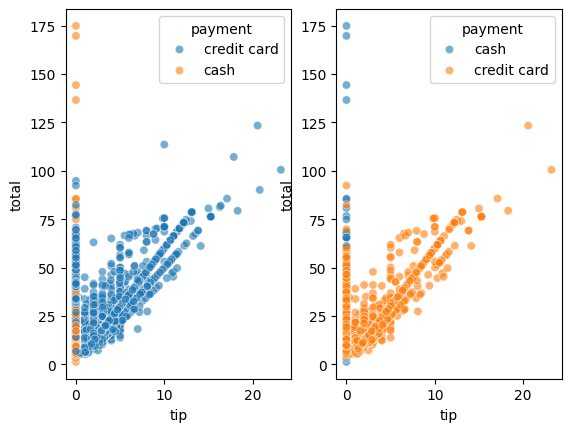

In [31]:
# imblearn을 활용한 랜덤언더샘플링
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42) #재현성을 위해 random_state=42으로 지정


X_payment = taxis.drop(columns = ['payment'])
y_payment = taxis['payment']

X_under, y_under = rus.fit_resample(X_payment, y_payment)

# 데이터 프레임 만들기
taxis_under = pd.DataFrame(X_under)
taxis_under['payment'] = y_under
taxis_under['payment'].value_counts()

# 산점도 그리기
plt.subplot(1,2,1)
sns.scatterplot(data=taxis, x='tip', y='total', hue ='payment', alpha=0.6)
plt.subplot(1,2,2)
sns.scatterplot(data=taxis_under, x='tip', y='total', hue ='payment', alpha=0.6)

# 색이 달라지긴 했지만 기존의 데이터에서 줄어든것을 볼 수 있다.

payment
cash           1786
credit card    3985
dtype: int64


<Axes: xlabel='tip', ylabel='total'>

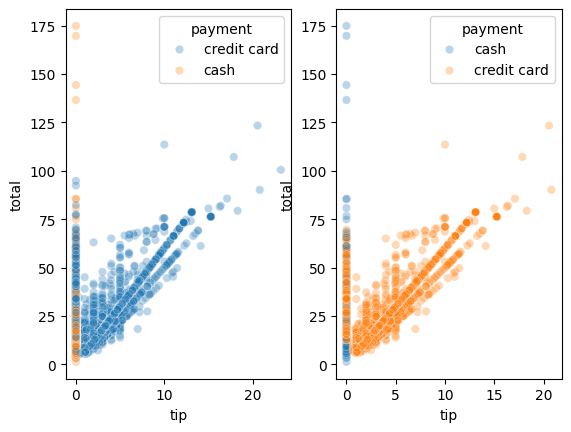

In [33]:
# ENN기법을 활용한 언더샘플링
from imblearn.under_sampling import EditedNearestNeighbours

enn = EditedNearestNeighbours()

# 거리계산 위해 수치형 데이터
X_payment_num = taxis.select_dtypes(include='number')
y_payment = taxis['payment']

# 샘플링
X_enn, y_enn = enn.fit_resample(X_payment_num, y_payment)

# 데이터프레임으로 변환
taxis_enn = pd.DataFrame(X_enn)
taxis_enn['payment'] = y_enn
print(taxis_enn.groupby('payment').size())

# 산점도 그리기
plt.subplot(1,2,1)
sns.scatterplot(data=taxis, x='tip', y='total', hue ='payment', alpha=0.3)
plt.subplot(1,2,2)
sns.scatterplot(data=taxis_enn, x='tip', y='total', hue ='payment', alpha=0.3)

# 경계에 있는 데이터

<Axes: xlabel='tip', ylabel='total'>

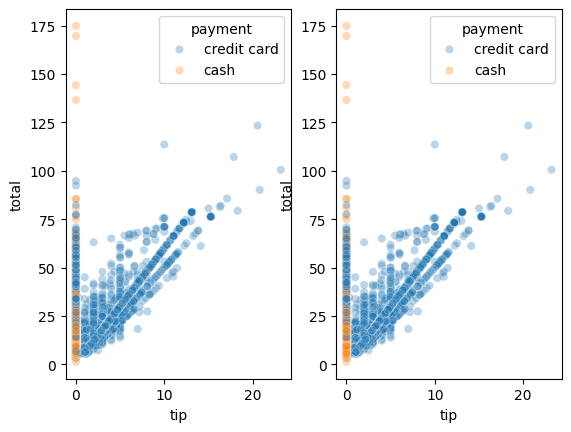

In [37]:
# Tomek link를 활용한 언더샘플링
from imblearn.under_sampling import TomekLinks

# 객체 신청
tomek = TomekLinks()

# 샘플링
X_tomek, y_tomek = tomek.fit_resample(X_payment_num, y_payment)

# 데이터프레임으로 변환
taxis_tomek = pd.DataFrame(X_tomek)
taxis_tomek['payment'] = y_tomek
taxis_tomek['payment'].value_counts()

# 산점도 그리기
plt.subplot(1,2,1)
sns.scatterplot(data=taxis, x='tip', y='total', hue ='payment', alpha=0.3)
plt.subplot(1,2,2)
sns.scatterplot(data=taxis_tomek, x='tip', y='total', hue ='payment', alpha=0.3)

# 많이 바뀌지 않은 것 확인

In [34]:
# 샘플링 결과 저장
# payment 가 클래스간의 차이가 크다, 데이터의 수가 적지 않다. -> 랜덤언더샘플링 결과
taxis_under.to_csv('taxis_done.csv', index=False)

#### [실습] 수출입 동향 데이터과 가격/기온/강수량/물가지수 병합
1. 월별 가격/기온/강수량/물가지수의 데이터를 연도기준으로 통합
2. 수출입동향 데이터와 병합
3. 수출입 동향 데이터를 월별 데이터로 복제
4. 월별 가격/기온/강수량/물가지수와 병합
5. 연도별 병합자료, 월별 병합자료에 대한 상관분석(price와 수출입동향간의 관계)
6. 종속변수(price)를 제외한 독립변수가 상관도가 높다면, 변수 선택(차원 축소)

1) 수출입은 년도별로 나머지는 월별 -> 데이터 크게 만들어서 채워보자(복제)<br>
2) 월별데이터를 년도로 통합해서 년도별 데이터로 만들기

3) 병합된 데이터로 상관분석 해보기

데이터 구조상 완벽하게 오버,언더샘플링 하기 힘들다.

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. 월별 가격/기온/강수량/물가지수의 데이터 연도기준으로 통합

In [51]:
df_price_merge = pd.read_csv('/content/drive/MyDrive/taxis/df_price_merge.csv')
df_price_merge.head()

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z
0,2020-01-01,4608,1.6,60.5,106.09,115.77,-2.4,18.9,-65.364248,-107.321243,-1.672028
1,2020-02-01,4366,2.5,53.1,106.06,114.81,1.6,60.5,-72.716873,-65.583936,-1.183558
2,2020-03-01,4343,7.7,16.3,105.97,115.96,2.5,53.1,-109.249050,-72.936258,-1.156009
3,2020-04-01,4508,11.1,16.9,105.55,116.78,7.7,16.3,-108.498360,-109.466750,-0.967571
4,2020-05-01,4793,18.0,112.4,105.32,114.88,11.1,16.9,-12.785927,-108.715229,-0.723177


In [52]:
df_price_merge['date'].dtypes # object
df_price_merge['date'] = pd.to_datetime(df_price_merge['date'])
df_price_merge['date'].dtypes # datetime으로 변경

# year, month 컬럼 추가
df_price_merge['year'] = df_price_merge['date'].dt.year
df_price_merge['month'] = df_price_merge['date'].dt.month
df_price_merge.head()

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,year,month
0,2020-01-01,4608,1.6,60.5,106.09,115.77,-2.4,18.9,-65.364248,-107.321243,-1.672028,2020,1
1,2020-02-01,4366,2.5,53.1,106.06,114.81,1.6,60.5,-72.716873,-65.583936,-1.183558,2020,2
2,2020-03-01,4343,7.7,16.3,105.97,115.96,2.5,53.1,-109.249050,-72.936258,-1.156009,2020,3
3,2020-04-01,4508,11.1,16.9,105.55,116.78,7.7,16.3,-108.498360,-109.466750,-0.967571,2020,4
4,2020-05-01,4793,18.0,112.4,105.32,114.88,11.1,16.9,-12.785927,-108.715229,-0.723177,2020,5


In [43]:
df_trade = pd.read_csv('/content/drive/MyDrive/taxis/df_trade.csv')
df_trade.head()

,Unnamed: 0,수출,수입,무역수지
0,2014,5224,19308,-25453
1,2015,5221,17902,-24117
2,2016,5581,17666,-23208
3,2017,6047,18594,-25467
4,2018,5985,19903,-28376


In [84]:
df_trade = df_trade.rename(columns={'Unnamed: 0':'년도'})
df_trade.head()

,년도,수출,수입,무역수지
0,2014,5224,19308,-25453
1,2015,5221,17902,-24117
2,2016,5581,17666,-23208
3,2017,6047,18594,-25467
4,2018,5985,19903,-28376


2. 수출입데이터와 병합 / 월별데이터로 복제

In [93]:
# 오버샘플링
merge_over = pd.merge(df_price_merge, df_trade ,left_on ='year', right_on='년도', how='left')
merge_over = merge_over.drop(columns={'년도'})
merge_over.head()

# year을 기준으로 월별 똑같이 복사

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,year,month,수출,수입,무역수지
0,2020-01-01,4608,1.6,60.5,106.09,115.77,-2.4,18.9,-65.364248,-107.321243,-1.672028,2020,1,6675.0,20669.0,-26715.0
1,2020-02-01,4366,2.5,53.1,106.06,114.81,1.6,60.5,-72.716873,-65.583936,-1.183558,2020,2,6675.0,20669.0,-26715.0
2,2020-03-01,4343,7.7,16.3,105.97,115.96,2.5,53.1,-109.249050,-72.936258,-1.156009,2020,3,6675.0,20669.0,-26715.0
3,2020-04-01,4508,11.1,16.9,105.55,116.78,7.7,16.3,-108.498360,-109.466750,-0.967571,2020,4,6675.0,20669.0,-26715.0
4,2020-05-01,4793,18.0,112.4,105.32,114.88,11.1,16.9,-12.785927,-108.715229,-0.723177,2020,5,6675.0,20669.0,-26715.0


3. df_price_merge의 월별데이터를 년도로 통합해서 수출입 데이터와 병합해 년도별 데이터로 만들기

In [72]:
df_price_merge_yearly = df_price_merge.groupby('year').mean().reset_index()
# reset_index()는 groupby로 'year'을 index로 설정한것을 다시 0, 1, 2,.. 원래의 인덱스로 돌려놓는다.
# 숫자형만 평균값을 구하고 싶을 때
#df_price_merge_yearly = df_price_merge.groupby('년도').mean(numeric_only=True).reset_index()

#date와 month의 평균은 필요없으므로 제외
df_price_merge_yearly = df_price_merge_yearly.drop(columns = ['date','month'])
df_price_merge_yearly

,year,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z
0,2020,5290.666667,13.233333,137.591667,105.852500,119.868333,13.058333,138.783333,12.168696,13.133668,0.014811
1,2021,4151.000000,13.700000,98.875000,107.325833,127.405833,13.625000,98.600000,-26.488861,-26.984072,-0.142405
2,2022,5013.916667,13.233333,147.941667,106.685833,111.665833,13.516667,147.466667,22.508445,21.828813,0.090027
3,2023,4070.083333,14.050000,133.233333,110.878333,115.798333,13.725000,127.208333,7.851017,1.600087,0.005275
4,2024,4794.666667,14.858333,109.283333,113.498333,124.136667,14.883333,115.966667,-16.039296,-9.578496,0.032292


In [75]:
# 언더 샘플링
merge_under = pd.merge(df_price_merge_yearly, df_trade, left_on='year', right_on='년도', how='left')
# how를 별도로 넣지 않으면 inner join 으로 결측치 없앨 수 있다.
merge_under

,year,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,년도,수출,수입,무역수지
0,2020,5290.666667,13.233333,137.591667,105.852500,119.868333,13.058333,138.783333,12.168696,13.133668,0.014811,2020.0,6675.0,20669.0,-26715.0
1,2021,4151.000000,13.700000,98.875000,107.325833,127.405833,13.625000,98.600000,-26.488861,-26.984072,-0.142405,2021.0,7543.0,25289.0,-33346.0
2,2022,5013.916667,13.233333,147.941667,106.685833,111.665833,13.516667,147.466667,22.508445,21.828813,0.090027,2022.0,7714.0,29764.0,-39747.0
3,2023,4070.083333,14.050000,133.233333,110.878333,115.798333,13.725000,127.208333,7.851017,1.600087,0.005275,2023.0,7994.0,27288.0,-34659.0
4,2024,4794.666667,14.858333,109.283333,113.498333,124.136667,14.883333,115.966667,-16.039296,-9.578496,0.032292,NaN,NaN,NaN,NaN


In [98]:
merge_over = merge_over.dropna() # 2024년 결측치 drop
merge_over.rename(columns={"수출" : "export",
                           "수입" : "import",
                           "무역수지" : "tradebalance"}, inplace = True) # 수출이 수입을 초과 하는지 안하는지 (흑자/적자)
merge_over.info() # 결측치 없음
merge_under = merge_under.dropna() # 2024년 결측치 drop
merge_under.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 0 to 47
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           48 non-null     datetime64[ns]
 1   price          48 non-null     int64         
 2   temperature    48 non-null     float64       
 3   rain           48 non-null     float64       
 4   index_total    48 non-null     float64       
 5   index_agr      48 non-null     float64       
 6   temperature+m  48 non-null     float64       
 7   rain+m         48 non-null     float64       
 8   temp*rain      48 non-null     float64       
 9   temp*rain+1    48 non-null     float64       
 10  temp*rain_Z    48 non-null     float64       
 11  year           48 non-null     int32         
 12  month          48 non-null     int32         
 13  export         48 non-null     float64       
 14  import         48 non-null     float64       
 15  tradebalance   48 non-null    

In [103]:
corr_price_monthly = merge_over.corr()
corr_price_monthly

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,year,month,export,import,tradebalance
date,1.000000,-0.146358,0.078198,0.069561,0.768820,-0.339394,0.180934,0.107581,0.069654,0.107907,0.156713,9.684228e-01,2.493089e-01,0.907219,7.898388e-01,-7.044846e-01
price,-0.146358,1.000000,0.469703,0.378532,-0.097476,0.281011,0.529534,0.783533,0.379170,0.783499,0.715332,-2.011095e-01,1.944063e-01,-0.247844,-1.183078e-01,9.197788e-02
temperature,0.078198,0.469703,1.000000,0.682038,0.206410,0.193805,0.844264,0.578140,0.683651,0.579500,0.772953,2.259773e-02,2.290368e-01,0.023128,7.925740e-03,-3.973965e-03
rain,0.069561,0.378532,0.682038,1.000000,0.112052,0.035401,0.593194,0.443509,0.999998,0.444385,0.563516,2.784943e-02,1.725570e-01,-0.007755,2.737285e-02,-2.583591e-02
index_total,0.768820,-0.097476,0.206410,0.112052,1.000000,0.110393,0.310824,0.189684,0.112444,0.190233,0.271883,7.219400e-01,2.796779e-01,0.649097,3.478495e-01,-2.393651e-01
index_agr,-0.339394,0.281011,0.193805,0.035401,0.110393,1.000000,0.301747,0.266966,0.035913,0.267324,0.309303,-4.015102e-01,1.974548e-01,-0.230110,-4.106862e-01,3.910167e-01
temperature+m,0.180934,0.529534,0.844264,0.593194,0.310824,0.301747,1.000000,0.689014,0.594520,0.690615,0.917850,2.132571e-02,6.444686e-01,0.024717,1.964587e-02,-1.817906e-02
rain+m,0.107581,0.783533,0.578140,0.443509,0.189684,0.266966,0.689014,1.000000,0.444339,0.999998,0.920084,1.088705e-02,3.892800e-01,-0.022308,1.841598e-02,-1.928085e-02
temp*rain,0.069654,0.379170,0.683651,0.999998,0.112444,0.035913,0.594520,0.444339,1.000000,0.445218,0.564688,2.786023e-02,1.728927e-01,-0.007670,2.734035e-02,-2.579466e-02
temp*rain+1,0.107907,0.783499,0.579500,0.444385,0.190233,0.267324,0.690615,0.999998,0.445218,1.000000,0.920948,1.092922e-02,3.904273e-01,-0.022186,1.843716e-02,-1.929574e-02


<Axes: >

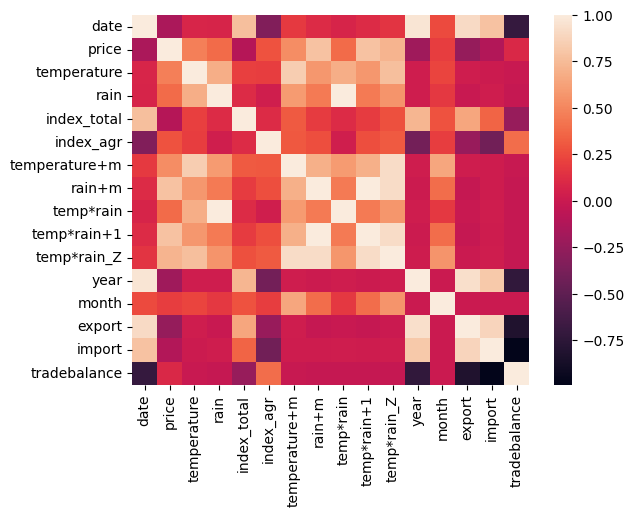

In [106]:
sns.heatmap(corr_price_monthly, fmt ='.2f')

In [102]:
merge_under.drop(columns=['년도'], inplace = True)
merge_under.rename(columns={"수출" : "export",
                           "수입" : "import",
                           "무역수지" : "tradebalance"}, inplace = True)
merge_under.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 3
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           4 non-null      int32  
 1   price          4 non-null      float64
 2   temperature    4 non-null      float64
 3   rain           4 non-null      float64
 4   index_total    4 non-null      float64
 5   index_agr      4 non-null      float64
 6   temperature+m  4 non-null      float64
 7   rain+m         4 non-null      float64
 8   temp*rain      4 non-null      float64
 9   temp*rain+1    4 non-null      float64
 10  temp*rain_Z    4 non-null      float64
 11  export         4 non-null      float64
 12  import         4 non-null      float64
 13  tradebalance   4 non-null      float64
dtypes: float64(13), int32(1)
memory usage: 464.0 bytes


In [107]:
core_price_yearly = merge_under.corr()
core_price_yearly

,year,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,export,import,tradebalance
year,1.000000,-0.589571,0.644847,0.218443,0.842506,-0.537789,0.829246,0.085740,0.219059,0.086277,0.270587,0.936762,0.815549,-0.727404
price,-0.589571,1.000000,-0.935033,0.639383,-0.789236,-0.362671,-0.870129,0.743900,0.638839,0.743564,0.613279,-0.726578,-0.346830,0.269642
temperature,0.644847,-0.935033,1.000000,-0.439174,0.925696,0.214304,0.758664,-0.567138,-0.438503,-0.566823,-0.447062,0.659967,0.226168,-0.113401
rain,0.218443,0.639383,-0.439174,1.000000,-0.073192,-0.928917,-0.333173,0.988877,1.000000,0.988941,0.992340,-0.060831,0.214705,-0.202650
index_total,0.842506,-0.789236,0.925696,-0.073192,1.000000,-0.168546,0.750219,-0.220628,-0.072449,-0.220224,-0.076047,0.757498,0.405941,-0.279340
index_agr,-0.537789,-0.362671,0.214304,-0.928917,-0.168546,1.000000,-0.033579,-0.881896,-0.929077,-0.882158,-0.956105,-0.308213,-0.550079,0.523734
temperature+m,0.829246,-0.870129,0.758664,-0.333173,0.750219,-0.033579,1.000000,-0.440673,-0.332664,-0.440173,-0.259089,0.961118,0.763926,-0.706889
rain+m,0.085740,0.743900,-0.567138,0.988877,-0.220628,-0.881896,-0.440673,1.000000,0.988766,1.000000,0.981189,-0.175684,0.145033,-0.151844
temp*rain,0.219059,0.638839,-0.438503,1.000000,-0.072449,-0.929077,-0.332664,0.988766,1.000000,0.988830,0.992330,-0.060304,0.214971,-0.202818
temp*rain+1,0.086277,0.743564,-0.566823,0.988941,-0.220224,-0.882158,-0.440173,1.000000,0.988830,1.000000,0.981296,-0.175137,0.145546,-0.152323


In [112]:
core_price_yearly['price'] # price 기준 확인

,price
year,-0.589571
price,1.000000
temperature,-0.935033
rain,0.639383
index_total,-0.789236
index_agr,-0.362671
temperature+m,-0.870129
rain+m,0.743900
temp*rain,0.638839
temp*rain+1,0.743564


<Axes: >

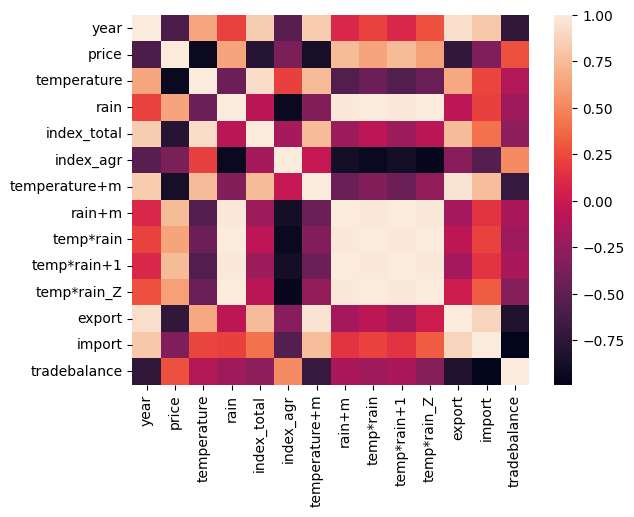

In [108]:
sns.heatmap(core_price_yearly, fmt='.2f')

- yearly 분석<br>
  - price - temp : 온도가 높을수록 가격 낮아지는 강한 음의 상관관계
  - price - rain : 강수량이 많을수록 가격이 오르는 중간 양의 상관관계
  - price - index_total : 종합 소비자 물가 지수 높을수록 가격 낮아짐
  - price - export : 수출량 많을수록 가격 낮아짐

  - temp - index_total: 온도높을 수록 지수 상승 (강한 양의 상관관계)
  - temp - export : 온도 높을수록 수출 증가 (중간 양의 상관관계)

  - import - export : 수출 수입 강한 양의 상관관계
  - import - tradebalance : 수입 증가할수록 무역수지 감소 (강한 음의 상관관계)


- monthly 분석
  - price - temp+m 중간 양의 상관관계
  - temp - rain 중간 양의 상관관계
  - temp*rain - temp*rain+1
    : 매우 강한 상관관계 (하나 선택)
  - index_total / index_agr : 기후변수들, pric와 낮은 상관관계
  - import - export : 강한 상관관계
  - export, import - tradebalance : 음의 상관관계

### 년도별 데이터 통합 분석
 export , import, trade_index 세개의 상관관계가 높으니 차원 축소

In [ ]:
#export와 index_total간의 상관관계가 높으나, index_total은 price와 상관관계 낮아 제외고려
# export, import, trade_index간의 상관관계가 높음 > 차원 축소
from sklearn.decomposition import PCA
# 상관도가 높은 컬럼 세개 선택
selected = merge_under.loc[:, ['export', 'import','tradebalance']]
pca = PCA(n_components=0.95)
trade_year_pca = pca. fit_transform(selected)
trade_year_pca.shape

(4, 1)

In [ ]:
# 축소된 차원 컬럼 추가
merge_under['trade'] = trade_year_pca
merge_under

<ipython-input-20-468621900841>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merge_under['trade'] = trade_year_pca


,year,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,export,import,tradebalance,trade
0,2020,5290.666667,13.233333,137.591667,105.852500,119.868333,13.058333,138.783333,12.168696,13.133668,0.014811,6675.0,20669.0,-26715.0,8606.986395
1,2021,4151.000000,13.700000,98.875000,107.325833,127.405833,13.625000,98.600000,-26.488861,-26.984072,-0.142405,7543.0,25289.0,-33346.0,484.187758
2,2022,5013.916667,13.233333,147.941667,106.685833,111.665833,13.516667,147.466667,22.508445,21.828813,0.090027,7714.0,29764.0,-39747.0,-7317.245000
3,2023,4070.083333,14.050000,133.233333,110.878333,115.798333,13.725000,127.208333,7.851017,1.600087,0.005275,7994.0,27288.0,-34659.0,-1773.929152


### 월별 데이터 통합분석

In [ ]:
merge_over.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 0 to 47
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           48 non-null     datetime64[ns]
 1   price          48 non-null     int64         
 2   temperature    48 non-null     float64       
 3   rain           48 non-null     float64       
 4   index_total    48 non-null     float64       
 5   index_agr      48 non-null     float64       
 6   temperature+m  48 non-null     float64       
 7   rain+m         48 non-null     float64       
 8   temp*rain      48 non-null     float64       
 9   temp*rain+1    48 non-null     float64       
 10  temp*rain_Z    48 non-null     float64       
 11  year           48 non-null     int32         
 12  month          48 non-null     int32         
 13  export         48 non-null     float64       
 14  import         48 non-null     float64       
 15  tradebalance   48 non-null    

In [ ]:
# 월별에 비해 년도별이 더 가격과 상관관계가 높은 것을 볼 수 있다 더 영향을 미침
# 상관도가 높은 컬럼 세개 선택
selected = merge_over.loc[:, ['export', 'import','tradebalance']]
pca = PCA(n_components=0.95)
trade_pca = pca. fit_transform(selected)
trade_pca.shape

(48, 1)

In [ ]:
# 축소된 차원 컬럼 추가
merge_over['trade'] = trade_pca
merge_over.head()

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,year,month,export,import,tradebalance,trade
0,2020-01-01,4608,1.6,60.5,106.09,115.77,-2.4,18.9,-65.364248,-107.321243,-1.672028,2020,1,6675.0,20669.0,-26715.0,8606.986395
1,2020-02-01,4366,2.5,53.1,106.06,114.81,1.6,60.5,-72.716873,-65.583936,-1.183558,2020,2,6675.0,20669.0,-26715.0,8606.986395
2,2020-03-01,4343,7.7,16.3,105.97,115.96,2.5,53.1,-109.249050,-72.936258,-1.156009,2020,3,6675.0,20669.0,-26715.0,8606.986395
3,2020-04-01,4508,11.1,16.9,105.55,116.78,7.7,16.3,-108.498360,-109.466750,-0.967571,2020,4,6675.0,20669.0,-26715.0,8606.986395
4,2020-05-01,4793,18.0,112.4,105.32,114.88,11.1,16.9,-12.785927,-108.715229,-0.723177,2020,5,6675.0,20669.0,-26715.0,8606.986395


**강사님풀이**

In [111]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [109]:
# 데이터를 불러오기
df = pd.read_csv('/content/drive/MyDrive/taxis/df_price_merge.csv')
trade = pd.read_csv('/content/drive/MyDrive/taxis/df_trade.csv')
trade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  10 non-null     int64
 1   수출          10 non-null     int64
 2   수입          10 non-null     int64
 3   무역수지        10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


In [ ]:
# trade의 컬럼명 변경
trade.rename(columns={'Unnamed: 0':'year',
                      '수출' : 'export',
                      '수입' : 'import',
                      '무역수지' : 'trade_index'
                      }, inplace=True)
trade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   year         10 non-null     int64
 1   export       10 non-null     int64
 2   import       10 non-null     int64
 3   trade_index  10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


In [ ]:
# 두개의 데이터 프레임의 산출기준 단위
print("수출입동향", trade['year'].unique())
print("4개 통합데이터", df['date'].unique())

수출입동향 [2014 2015 2016 2017 2018 2019 2020 2021 2022 2023]
4개 통합데이터 ['2020-01-01' '2020-02-01' '2020-03-01' '2020-04-01' '2020-05-01'
 '2020-06-01' '2020-07-01' '2020-08-01' '2020-09-01' '2020-10-01'
 '2020-11-01' '2020-12-01' '2021-01-01' '2021-02-01' '2021-03-01'
 '2021-04-01' '2021-05-01' '2021-06-01' '2021-07-01' '2021-08-01'
 '2021-09-01' '2021-10-01' '2021-11-01' '2021-12-01' '2022-01-01'
 '2022-02-01' '2022-03-01' '2022-04-01' '2022-05-01' '2022-06-01'
 '2022-07-01' '2022-08-01' '2022-09-01' '2022-10-01' '2022-11-01'
 '2022-12-01' '2023-01-01' '2023-02-01' '2023-03-01' '2023-04-01'
 '2023-05-01' '2023-06-01' '2023-07-01' '2023-08-01' '2023-09-01'
 '2023-10-01' '2023-11-01' '2023-12-01' '2024-01-01' '2024-02-01'
 '2024-03-01' '2024-04-01' '2024-05-01' '2024-06-01' '2024-07-01'
 '2024-08-01' '2024-09-01' '2024-10-01' '2024-11-01' '2024-12-01']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           60 non-null     object 
 1   price          60 non-null     int64  
 2   temperature    60 non-null     float64
 3   rain           60 non-null     float64
 4   index_total    60 non-null     float64
 5   index_agr      60 non-null     float64
 6   temperature+m  60 non-null     float64
 7   rain+m         60 non-null     float64
 8   temp*rain      60 non-null     float64
 9   temp*rain+1    60 non-null     float64
 10  temp*rain_Z    60 non-null     float64
 11  year           60 non-null     int32  
dtypes: float64(9), int32(1), int64(1), object(1)
memory usage: 5.5+ KB


In [ ]:
# 4개의 통합데이터를 연도별 기준으로 통합
# 연도의 컬럼을 생성 (date를 datetime으로 변경하고 연도를 추출, 스트링에서 처음 4글자자르기)
df['year'] = pd.to_datetime(df['date']).dt.year

# 연도별 각컬럼의 평균
df_year = df.iloc[:,1:].groupby('year').mean()
df_year

,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z
year,,,,,,,,,,
2020,5290.666667,13.233333,137.591667,105.852500,119.868333,13.058333,138.783333,12.168696,13.133668,0.014811
2021,4151.000000,13.700000,98.875000,107.325833,127.405833,13.625000,98.600000,-26.488861,-26.984072,-0.142405
2022,5013.916667,13.233333,147.941667,106.685833,111.665833,13.516667,147.466667,22.508445,21.828813,0.090027
2023,4070.083333,14.050000,133.233333,110.878333,115.798333,13.725000,127.208333,7.851017,1.600087,0.005275
2024,4794.666667,14.858333,109.283333,113.498333,124.136667,14.883333,115.966667,-16.039296,-9.578496,0.032292


In [ ]:
# df_year와 trade를 병합
df_merge_year = pd.merge(df_year, trade, on='year')
df_merge_year

,year,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,export,import,trade_index
0,2020,5290.666667,13.233333,137.591667,105.852500,119.868333,13.058333,138.783333,12.168696,13.133668,0.014811,6675,20669,-26715
1,2021,4151.000000,13.700000,98.875000,107.325833,127.405833,13.625000,98.600000,-26.488861,-26.984072,-0.142405,7543,25289,-33346
2,2022,5013.916667,13.233333,147.941667,106.685833,111.665833,13.516667,147.466667,22.508445,21.828813,0.090027,7714,29764,-39747
3,2023,4070.083333,14.050000,133.233333,110.878333,115.798333,13.725000,127.208333,7.851017,1.600087,0.005275,7994,27288,-34659


year            -0.589571
price            1.000000
temperature     -0.935033
rain             0.639383
index_total     -0.789236
index_agr       -0.362671
temperature+m   -0.870129
rain+m           0.743900
temp*rain        0.638839
temp*rain+1      0.743564
temp*rain_Z      0.613279
export          -0.726578
import          -0.346830
trade_index      0.269642
Name: price, dtype: float64


<Axes: >

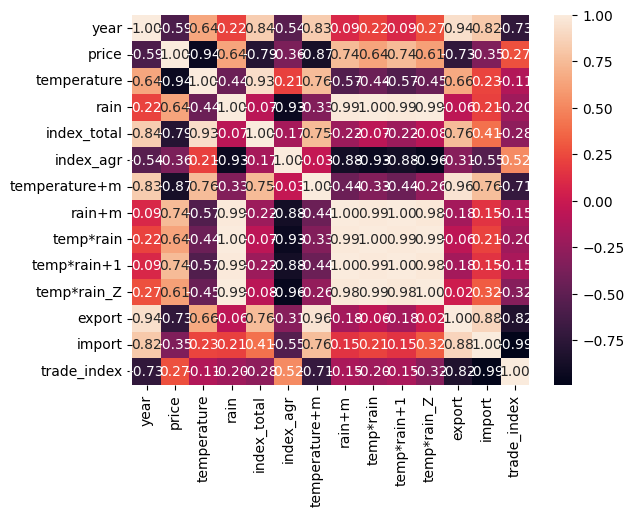

In [ ]:
# 상관분석
corr_merge_year = df_merge_year.corr()
print(corr_merge_year['price'])

# 히트맵 그리기
sns.heatmap(corr_merge_year, annot=True, fmt='.2f')

In [ ]:
# export와 index_total간의 상관관계가 높으나, index_total은 price와 상관도가 낮으므로 향후 분석시 제외 고려
# export, import, trade_index간의 상관관계가 높음 > 차원 축소
from sklearn.decomposition import PCA
# 상관도가 높은 컬럼 세개 선택
selected = df_merge_year.loc[:, ['export', 'import', 'trade_index']]
pca = PCA(n_components=0.95)
trade_year_pca = pca.fit_transform(selected)
trade_year_pca.shape

(4, 1)

In [ ]:
# 축소된 차원 컬럼 추가
df_merge_year['trade'] = trade_year_pca
df_merge_year

,year,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,export,import,trade_index,trade
0,2020,5290.666667,13.233333,137.591667,105.852500,119.868333,13.058333,138.783333,12.168696,13.133668,0.014811,6675,20669,-26715,8606.986395
1,2021,4151.000000,13.700000,98.875000,107.325833,127.405833,13.625000,98.600000,-26.488861,-26.984072,-0.142405,7543,25289,-33346,484.187758
2,2022,5013.916667,13.233333,147.941667,106.685833,111.665833,13.516667,147.466667,22.508445,21.828813,0.090027,7714,29764,-39747,-7317.245000
3,2023,4070.083333,14.050000,133.233333,110.878333,115.798333,13.725000,127.208333,7.851017,1.600087,0.005275,7994,27288,-34659,-1773.929152


#### 월별 데이터 통합 분석

In [ ]:
# 수출입동향 데이터 12개월 복사하여 병합
df_merge = pd.merge(df, trade, on='year', how='left')
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           60 non-null     object 
 1   price          60 non-null     int64  
 2   temperature    60 non-null     float64
 3   rain           60 non-null     float64
 4   index_total    60 non-null     float64
 5   index_agr      60 non-null     float64
 6   temperature+m  60 non-null     float64
 7   rain+m         60 non-null     float64
 8   temp*rain      60 non-null     float64
 9   temp*rain+1    60 non-null     float64
 10  temp*rain_Z    60 non-null     float64
 11  year           60 non-null     int32  
 12  export         48 non-null     float64
 13  import         48 non-null     float64
 14  trade_index    48 non-null     float64
dtypes: float64(12), int32(1), int64(1), object(1)
memory usage: 6.9+ KB


In [ ]:
df_merge.head()

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,year,export,import,trade_index
0,2020-01-01,4608,1.6,60.5,106.09,115.77,-2.4,18.9,-65.364248,-107.321243,-1.672028,2020,6675.0,20669.0,-26715.0
1,2020-02-01,4366,2.5,53.1,106.06,114.81,1.6,60.5,-72.716873,-65.583936,-1.183558,2020,6675.0,20669.0,-26715.0
2,2020-03-01,4343,7.7,16.3,105.97,115.96,2.5,53.1,-109.249050,-72.936258,-1.156009,2020,6675.0,20669.0,-26715.0
3,2020-04-01,4508,11.1,16.9,105.55,116.78,7.7,16.3,-108.498360,-109.466750,-0.967571,2020,6675.0,20669.0,-26715.0
4,2020-05-01,4793,18.0,112.4,105.32,114.88,11.1,16.9,-12.785927,-108.715229,-0.723177,2020,6675.0,20669.0,-26715.0
5,2020-06-01,4372,23.9,139.6,105.51,115.69,18.0,112.4,14.649657,-13.002147,0.236090,2020,6675.0,20669.0,-26715.0
6,2020-07-01,4885,24.1,270.4,105.42,116.26,23.9,139.6,145.329011,14.434590,0.788726,2020,6675.0,20669.0,-26715.0
7,2020-08-01,7422,26.5,675.7,106.05,122.81,24.1,270.4,550.334387,145.112555,1.445664,2020,6675.0,20669.0,-26715.0
8,2020-09-01,10740,21.4,181.5,106.51,131.82,26.5,675.7,56.396920,550.114065,3.607694,2020,6675.0,20669.0,-26715.0
9,2020-10-01,7242,14.3,0.0,105.96,130.67,21.4,181.5,-125.239237,56.180777,0.817084,2020,6675.0,20669.0,-26715.0


In [ ]:
df_merge.tail(0)

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,year,export,import,trade_index
55,2024-08-01,6397,29.3,72.8,113.94,125.40,26.6,557.3,-51.843909,431.837106,3.032991,2024,NaN,NaN,NaN
56,2024-09-01,8172,25.5,143.9,113.92,127.46,29.3,72.8,19.016591,-52.056911,0.843950,2024,NaN,NaN,NaN
57,2024-10-01,8240,16.7,74.0,114.04,125.26,25.5,143.9,-51.205739,18.801871,0.923477,2024,NaN,NaN,NaN
58,2024-11-01,3627,9.7,60.0,113.73,119.14,16.7,74.0,-65.503340,-51.421857,-0.044920,2024,NaN,NaN,NaN
59,2024-12-01,4327,0.8,5.7,114.24,123.10,9.7,60.0,-120.145570,-65.721028,-0.610807,2024,NaN,NaN,NaN


In [ ]:
# 결측치 제거
df_merge.dropna(inplace=True)
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 0 to 47
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           48 non-null     object 
 1   price          48 non-null     int64  
 2   temperature    48 non-null     float64
 3   rain           48 non-null     float64
 4   index_total    48 non-null     float64
 5   index_agr      48 non-null     float64
 6   temperature+m  48 non-null     float64
 7   rain+m         48 non-null     float64
 8   temp*rain      48 non-null     float64
 9   temp*rain+1    48 non-null     float64
 10  temp*rain_Z    48 non-null     float64
 11  year           48 non-null     int32  
 12  export         48 non-null     float64
 13  import         48 non-null     float64
 14  trade_index    48 non-null     float64
dtypes: float64(12), int32(1), int64(1), object(1)
memory usage: 5.8+ KB


price            1.000000
temperature      0.469703
rain             0.378532
index_total     -0.097476
index_agr        0.281011
temperature+m    0.529534
rain+m           0.783533
temp*rain        0.379170
temp*rain+1      0.783499
temp*rain_Z      0.715332
year            -0.201109
export          -0.247844
import          -0.118308
trade_index      0.091978
Name: price, dtype: float64


<Axes: >

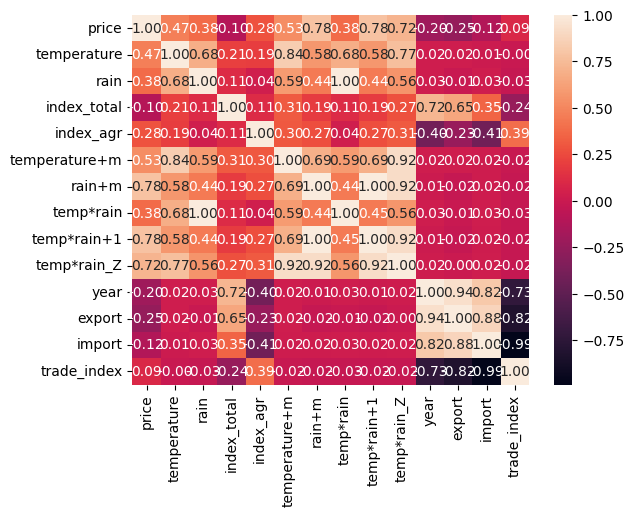

In [ ]:
# 상관분석
corr_merge = df_merge.iloc[:, 1:].corr()
print(corr_merge['price'])

# 히트맵
sns.heatmap(corr_merge, annot=True, fmt='.2f')

<Axes: >

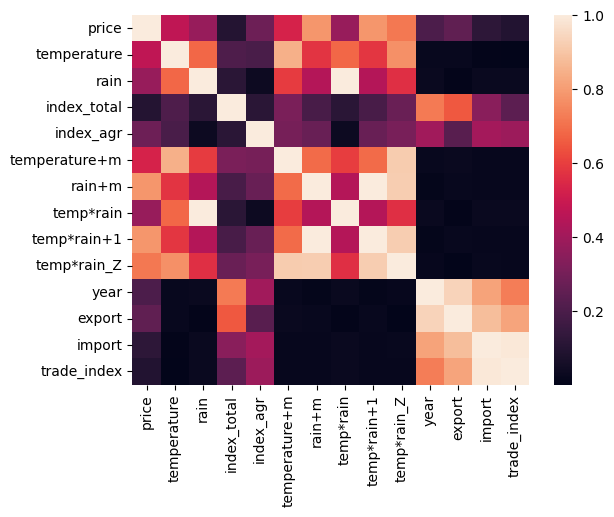

In [ ]:
corr_merge_abs = abs(corr_merge)
sns.heatmap(corr_merge_abs)

In [ ]:
# 상관도가 높은 컬럼 세개 선택
selected = df_merge.loc[:, ['export', 'import', 'trade_index']]
pca = PCA(n_components=0.95)
trade_pca = pca.fit_transform(selected)
trade_pca.shape

(48, 1)

In [ ]:
df_merge['trade'] = trade_pca
df_merge.head()

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z,year,export,import,trade_index,trade
0,2020-01-01,4608,1.6,60.5,106.09,115.77,-2.4,18.9,-65.364248,-107.321243,-1.672028,2020,6675.0,20669.0,-26715.0,8606.986395
1,2020-02-01,4366,2.5,53.1,106.06,114.81,1.6,60.5,-72.716873,-65.583936,-1.183558,2020,6675.0,20669.0,-26715.0,8606.986395
2,2020-03-01,4343,7.7,16.3,105.97,115.96,2.5,53.1,-109.249050,-72.936258,-1.156009,2020,6675.0,20669.0,-26715.0,8606.986395
3,2020-04-01,4508,11.1,16.9,105.55,116.78,7.7,16.3,-108.498360,-109.466750,-0.967571,2020,6675.0,20669.0,-26715.0,8606.986395
4,2020-05-01,4793,18.0,112.4,105.32,114.88,11.1,16.9,-12.785927,-108.715229,-0.723177,2020,6675.0,20669.0,-26715.0,8606.986395
